# Firm characteristics: the same factor structure with a nonlinear map

[`08a_ipca`](08a_ipca.ipynb) required a firm's exposure to each latent factor to be a **linear**
function of its characteristics that month. That constraint is what let one map be estimated on
the whole panel instead of 57 weights on one cross-section, and it is also the assumption most
likely to be wrong: nothing says the relationship between a firm's book-to-market rank and its
exposure to a value factor is a straight line, and a product of two characteristics - which
`03_financial_features` builds explicitly for exactly this reason - is not linear in either.

The **conditional autoencoder** keeps everything else and replaces only that map. A network takes
the firm's characteristics and returns its exposures; a second, linear part of the model turns
the month's cross-section of returns into that month's factor returns; the predicted return is
the product, as it was in IPCA. So the difference between this notebook and the last one is the
shape of one function, which is what makes them worth reading against each other.

**This one has a stopping point and the last one did not.** IPCA runs alternating least squares
to convergence, so a fold produces one fitted map. A network is trained for a declared number of
epochs, and its state after 5 epochs is a different model from its state after 50 - so
`case_studies/config/cae/cae.yaml` declares both the budget and how often to save, and every
saved state becomes its own registered prediction set. The checkpoint is part of the
configuration, not a detail of how it was fitted.

**Learning objectives**

- Separate what a latent-factor model assumes about structure from what it assumes about
  functional form.
- Read a checkpoint path and tell a model that has converged from one still learning or one
  that has begun to fit its training window.
- See why every checkpoint is published rather than the one whose validation IC is highest.

**Book reference**: Chapter 14, Section 14.6 (The conditional autoencoder). Chapter 6,
Section 6.7 (Search accounting and run logging) introduces the run log this notebook writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_evaluation`](04_evaluation.ipynb), [`08_latent_factors`](08_latent_factors.ipynb) and
[`08a_ipca`](08a_ipca.ipynb), which is the linear version of this model.

**What it writes**: one training run per label and one complete validation prediction set per
label and epoch checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a population named for this model. The family splits across
four notebooks, so each publishes its own population rather than one shared one.
[`11_backtest`](11_backtest.ipynb) reads them and selects on validation backtest Sharpe.
**Selection happens there, not here**, and the checkpoint is part of what is selected.

In [1]:
"""Fit the declared firm-characteristics conditional-autoencoder population."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

MODEL_NAME = "cae"

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and all three do:
`fwd_ret_1m`, `fwd_ret_1m_win` - the same return with each month's cross-section clipped at its
own tails - and `fwd_class_1m`, which turns that return into a class.

In [4]:
declared_labels(study, "latent_factors")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

`case_studies/config/cae/cae.yaml` declares the factor count, the training budget and the
checkpoint interval. The budget and the interval together decide the checkpoint surface: a state
is saved every `checkpoint_interval` epochs up to `n_epochs`, and each saved state becomes a
registered prediction set covering the whole validation period. That is why the plan below shows
ten checkpoints where [`08a_ipca`](08a_ipca.ipynb) shows one. The runtime comes from
`config/setup.yaml` under `modeling.latent_factors` and is CUDA, which this model can use and
IPCA cannot.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""latent_factors""","""fwd_class_1m""","""cae""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_1m""","""cae""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_1m_win""","""cae""","""""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across four notebooks and each publishes one model, so the complete
catalog is four times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Planning reads the label and feature files, computes the fold boundaries from the walk-forward
parameters in `config/setup.yaml`, works out the exact rows each fit must predict, and derives
every training and prediction identity - without fitting anything. Four things to check:

- **`feature_count` and `eligible_rows` agree across the rows.** A row that differs is a label
  measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`04_evaluation`](04_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out 2016 tail visible.
- **`checkpoints` is how many training states each label will publish predictions for.**
  Multiply it by the number of rows to get the number of candidate models this notebook creates.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="08b_conditional_autoencoder",
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_class_1m""","""cae""","""classification""",57,252008,10,10,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m""","""cae""","""regression""",57,252008,10,10,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m_win""","""cae""","""regression""",57,252008,10,10,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares, or published fewer checkpoints than the configuration does, would still print an
IC table and still register its rows; what it would not do is announce the gap.

In [8]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded conditional-autoencoder menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

3 label-configuration pairs
3 training identities
30 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. takes the firm-months inside that fold's training window,
2. trains the network that maps a firm's characteristics to its exposures jointly with the
   linear part that turns each month's returns into factor returns, for the declared number of
   epochs, saving the fitted state at each checkpoint on the way,
3. applies each saved state to the validation months' characteristics to get exposures there,
   and multiplies by the factor returns to get a predicted return.

Step 3 is what makes one fit produce many results. Fold predictions are concatenated into one
series per checkpoint covering the whole validation period, and each becomes its own registered
prediction set with its own identity. Nothing here chooses among them.

**This notebook passes the plan rather than resolved requests, and on this family that changes
what the plan table could show rather than how the fitting is ordered.** The linear, boosted and
TabM adapters each provide a batch runner that prepares one fold set for several configurations;
the latent-factor adapter provides none, so every request is fitted on its own whichever path is
taken. There is nothing here for a batch runner to share in any case: this notebook publishes one
model against three labels, and each label is a different set of rows. What passing the plan does
cost is `eligible_entities`, which needs the eligibility keys themselves; `eligible_rows` above
moves whenever the universe does, so the check that column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [9]:
population_name = POPULATION_NAME or f"us_firm_characteristics-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

Latent factor CV: 1 models × 10 folds
Log file: ~/ml4t/artifacts/case_studies/us_firm_characteristics/run_log/training/8425c2aaa603/.models.337dc32d03884071948b4cc19aa57717.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=50
  cae (K=5):


    Fold 0: ragged train=118, val=11, max_N=2826


      fold 0: reported_epoch=50, IC=+0.1386, 10.8s


    Fold 1: ragged train=119, val=11, max_N=2826


      fold 1: reported_epoch=50, IC=+0.1280, 11.5s


...

      fold 8: reported_epoch=50, IC=+0.0522, 12.5s


    Fold 9: ragged train=118, val=11, max_N=2826


      fold 9: reported_epoch=50, IC=-0.0529, 13.1s
    -> best epoch=50, IC=+0.0220 (143.6s)


  Best: cae (IC=+0.0220)


3 configurations fitted
population us_firm_characteristics-cae-validation-v1: 30 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

**There are no fold counts above, and their absence is the honest reading rather than an
omission.** [`05_linear`](05_linear.ipynb), [`06_gbm`](06_gbm.ipynb) and
[`07_tabular_dl`](07_tabular_dl.ipynb) each print folds fitted against folds served from the
registry, because their runners record `fitted_folds` and `reused_folds` per run. The
latent-factor runner records neither - its result carries no diagnostics at all, so the only
per-run keys are the status and the training hash. Printing two zeros here would say every fold
came from cache, which is the opposite of what nothing-recorded means.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "latent_factors", labels=["fwd_ret_1m"], config_names=["cae"])
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-cae-v1")
```

To change the factor count, the training budget or the checkpoint interval, edit
`case_studies/config/cae/cae.yaml`. Each changes this configuration's identity - the interval as
much as the budget, because it changes which states exist - so the result registers as a new row
beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label and epoch checkpoint. `ic_mean` is the **information coefficient**: in each
validation month, rank the firms by the model's prediction, rank them by the return they went on
to earn, correlate the two rankings, and average that monthly correlation over the validation
period.

**Every count and aggregate below is keyed on `(label, checkpoint_value)`.** Grouping on the
checkpoint alone would average across targets; grouping on the label alone would collapse the
training path this notebook exists to show.

The published catalog is checked against the population planned before fitting rather than
against its own row count, because a run that lost a member would otherwise report a shorter
table and nothing else.

In [10]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    pl.col("direction_label").alias("auc_scored_against"),
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "checkpoint_value"])

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial conditional-autoencoder checkpoint cannot pass to backtesting")
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label and checkpoint must identify one prediction set")
if catalog.get_column("checkpoint_value").null_count():
    raise RuntimeError("every checkpoint must name the epoch it was taken at")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(panel_labels)} labels")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "label",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "full_coverage",
).head(15)

30 candidate models across 3 labels
at 10 checkpoints each


label,checkpoint_value,ic_mean,ic_std,ic_t,ic_n_days,full_coverage
str,i64,f64,f64,f64,f64,bool
"""fwd_class_1m""",5,0.025201,0.044733,1.781501,110.0,true
"""fwd_class_1m""",10,0.069787,0.033788,6.531544,110.0,true
"""fwd_class_1m""",15,0.074852,0.038999,6.069531,110.0,true
"""fwd_class_1m""",20,0.075221,0.040093,5.932939,110.0,true
"""fwd_class_1m""",25,0.074095,0.040741,5.751141,110.0,true
…,…,…,…,…,…,…
"""fwd_ret_1m""",5,-0.051696,0.045687,-3.578205,110.0,true
"""fwd_ret_1m""",10,-0.039057,0.044069,-2.802579,110.0,true
"""fwd_ret_1m""",15,-0.03793,0.053585,-2.238431,110.0,true


### What more training does

Each line traces one label's out-of-sample IC as epochs are added, and the shape to read is where
it reaches its highest point.

A line that rises and then flattens has learned what it is going to learn. A line still climbing
at the last checkpoint has not converged at the declared budget, so its final number is a lower
bound rather than a level. A line that peaks early and then falls is the third case: the network
is still improving its reconstruction of the training window while the ranking it produces out of
sample gets worse. All three are published, because which one a reader is looking at is a fact
about the data rather than something to resolve away before the backtest sees it.

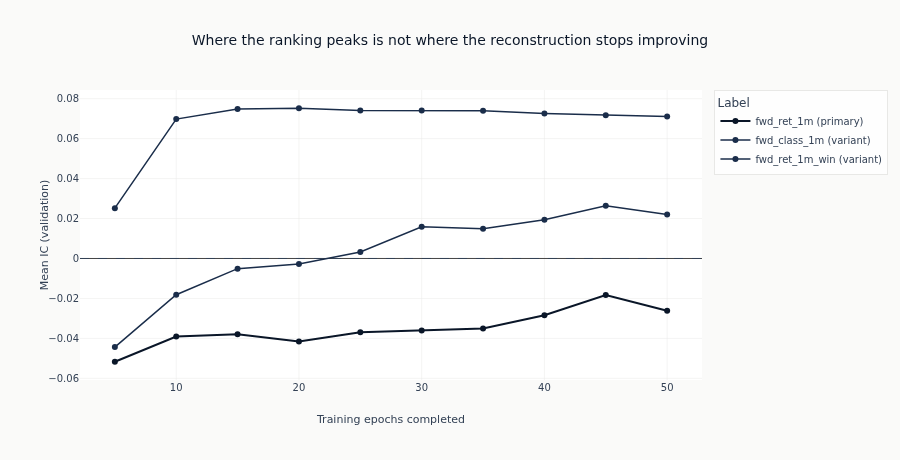

In [11]:
curves = catalog.filter("full_coverage").sort("label", "checkpoint_value")
fig = go.Figure()
for label in panel_labels:
    series = curves.filter(pl.col("label") == label).sort("checkpoint_value")
    fig.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines+markers",
            name=f"{label} ({'primary' if label == primary else 'variant'})",
            line=dict(
                color=COLORS["blue"] if label == primary else COLORS["slate"],
                width=2 if label == primary else 1.5,
            ),
            marker=dict(size=6),
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_xaxes(title_text="Training epochs completed")
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_layout(
    title="Where the ranking peaks is not where the reconstruction stops improving",
    height=460,
    width=900,
    margin=dict(t=90),
    legend=dict(title_text="Label"),
)
# Where each line peaks is a fact about the frame, so the alt text counts it rather than asserting
# a shape the next run may not reproduce.
peaks = (
    curves.group_by("label")
    .agg(
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .sort("label")
)
peak_text = "; ".join(
    f"{row['label']} peaks at epoch {row['peak_checkpoint']} of "
    f"{row['first_checkpoint']} to {row['last_checkpoint']}"
    for row in peaks.iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Line chart of mean validation information coefficient against training epochs completed, one "
    "line per label with a marker at each declared checkpoint: the primary target in dark navy and "
    "the two variants in slate, over a dashed zero line. Counted from the frame: "
    f"{peak_text}.",
)

### How much the stopping point is worth

The frame below puts the range a label's IC covers across its own checkpoints against the spread
across labels at a fixed amount of training. That is the quantity deciding whether the stopping
point is a decision worth making carefully or one being made by noise, and both sides are
computed within this model so the comparison is not smuggling in a difference between models.

In [12]:
final_epoch = int(curves.get_column("checkpoint_value").max())
checkpoint_vs_label = (
    curves.group_by("label")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_epoch).first(),
        scored_months=pl.col("ic_n_days").max(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("label")
)
across_labels = float(
    checkpoint_vs_label.get_column("ic_final").max()
    - checkpoint_vs_label.get_column("ic_final").min()
)
print(f"compared at {final_epoch} epochs; spread across labels there: {across_labels:.4f}")
checkpoint_vs_label

compared at 50 epochs; spread across labels there: 0.0973


label,ic_min,ic_max,ic_final,scored_months,checkpoint_range
str,f64,f64,f64,f64,f64
"""fwd_class_1m""",0.025201,0.075221,0.071147,110.0,0.05002
"""fwd_ret_1m""",-0.051696,-0.018339,-0.026187,110.0,0.033357
"""fwd_ret_1m_win""",-0.044365,0.026351,0.02199,110.0,0.070716


## 5. What to notice

**This model and [`08a_ipca`](08a_ipca.ipynb) differ in one function and nothing else.** Same
characteristics, same folds, same months scored, same factor count, same conditional-factor
structure - a firm's exposure comes from its own characteristics, and the predicted return is
that exposure times the month's factor return. What changes is whether the map from
characteristics to exposures is a matrix or a network. So a gap between the two notebooks is
evidence about functional form, and it is one of the few comparisons in this case study clean
enough to read that way.

**A relaxed constraint is not free.** The linear map had few enough parameters that the whole
panel could pin them down; a network has enough that it can fit the training window's noise as
well as its structure, and the checkpoint path is where that becomes visible. This is the same
tension [`07_tabular_dl`](07_tabular_dl.ipynb) shows under a different architecture, and it is
why both notebooks publish every checkpoint rather than a chosen one.

**The checkpoint is part of the configuration, and that is a deliberate cost.** Publishing ten
states per label makes the downstream backtest ten times larger than it would be if this notebook
picked one. Picking one would mean picking it on validation IC, and IC is not what the strategy
is selected on - so the choice would be made by the wrong quantity, and made somewhere the reader
cannot see it. `checkpoint_vs_label` is how to judge whether that cost is buying anything on this
data: where the within-label range across checkpoints exceeds the spread across labels at a fixed
epoch, the stopping point matters more than the target does.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover. Selection is on validation
backtest Sharpe in [`11_backtest`](11_backtest.ipynb), where the checkpoint is part of what is
selected.

**Known limitations.** The factor count, the training budget, the checkpoint interval and the
network's width are declared rather than chosen, and nothing here searches over them - a search
over validation IC is what this arrangement exists to avoid. The IC is an average of monthly rank
correlations with no adjustment for serial dependence, so `ic_t` is a diagnostic rather than a
test. And every number is measured on validation folds that have been read many times over by the
time a case study reaches this notebook.

**Next**: [`08c_stochastic_discount_factor`](08c_stochastic_discount_factor.ipynb) drops the
two-stage structure both of these share. Instead of estimating a factor representation and then
forecasting it, it learns the pricing object directly from a no-arbitrage condition - so there is
no factor-return history to hand to a second stage at all.